## Load RNN and compare against HMM at forecasting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import rpy2.robjects as robjects

2026-04-08 13:31:56.570396: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 13:31:56.583919: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775680316.596978  703135 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775680316.601050  703135 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775680316.613427  703135 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
from forecast_research.energy_price.custom_losses import (
    dirichlet_layer,
    EvidentialLoss,
    AnnealingCallback,
    evidential_kl_divergence,
    cross_entropy_loss,
)

from forecast_research.energy_price.helpers import (
    load_rds_array
)

In [3]:
X_train,     (_, _, feature_names)   = load_rds_array('energy_data/X_train.rds')
Y_train,     (_, _, state_names)     = load_rds_array('energy_data/Y_train.rds')
Y_hat_train, _                       = load_rds_array('energy_data/Y_hat_train.rds')

X_valid,     _ = load_rds_array('energy_data/X_valid.rds')
Y_valid,     _ = load_rds_array('energy_data/Y_valid.rds')
Y_hat_valid, _ = load_rds_array('energy_data/Y_hat_valid.rds')
Y_date_valid = Y_valid[:, :, 0]  # Extract date dimension for validation set
Y_valid = Y_valid[:, :, 1:].astype(float)  # Extract state probabilities and convert to numeric
Y_hat_valid = Y_hat_valid[:, :, 1:].astype(float)  # Extract state probabilities for validation set predictions

X_test,      _ = load_rds_array('energy_data/X_test.rds')
Y_test,      _ = load_rds_array('energy_data/Y_test.rds')
Y_hat_test,  _ = load_rds_array('energy_data/Y_hat_test.rds')
Y_date_test = Y_test[:, :, 0]  # Extract date dimension for test set
Y_test = Y_test[:, :, 1:].astype(float)  # Extract state probabilities and convert to numeric
Y_hat_test = Y_hat_test[:, :, 1:].astype(float)  # Extract state probabilities for test set predictions

forecast_horizon = Y_test.shape[1]

print("X_train:    ", X_train.shape)
print("Y_train:    ", Y_train.shape)
print("Feature names:", feature_names)
print("State names:  ", state_names)

X_train:     (3510, 10, 14)
Y_train:     (3510, 10, 4)
Feature names: ['date', 'renewable_penetration', 'renewable_penetration_30d_avg', 'gas_share', 'gas_share_30d_avg', 'coal_share', 'coal_share_30d_avg', 'net_export_ratio', 'relative_demand', 'gas_price', 'month', 'state_prob_1', 'state_prob_2', 'state_prob_3']
State names:   ['date', 'gt_1', 'gt_2', 'gt_3']


In [4]:
# Load training data
X_train_cov = np.load('energy_data/ml_data/X_train_cov.npy')
X_train_dt = np.load('energy_data/ml_data/X_train_dt.npy')
horizon_train = np.load('energy_data/ml_data/horizon_train.npy')
Y_train_h = np.load('energy_data/ml_data/Y_train_h.npy')
dates_train = np.load('energy_data/ml_data/dates_train.npy')
Y_dates_train = np.load('energy_data/ml_data/Y_dates_train.npy')
Y_month_train = np.load('energy_data/ml_data/Y_month_train.npy')

# Load validation data
X_valid_cov = np.load('energy_data/ml_data/X_valid_cov.npy')
X_valid_dt = np.load('energy_data/ml_data/X_valid_dt.npy')
horizon_valid = np.load('energy_data/ml_data/horizon_valid.npy')
Y_valid_h = np.load('energy_data/ml_data/Y_valid_h.npy')
dates_valid = np.load('energy_data/ml_data/dates_valid.npy')
Y_dates_valid = np.load('energy_data/ml_data/Y_dates_valid.npy')
Y_month_valid = np.load('energy_data/ml_data/Y_month_valid.npy')

# Load test data
X_test_cov = np.load('energy_data/ml_data/X_test_cov.npy')
X_test_dt = np.load('energy_data/ml_data/X_test_dt.npy')
horizon_test = np.load('energy_data/ml_data/horizon_test.npy')
Y_test_h = np.load('energy_data/ml_data/Y_test_h.npy')
dates_test = np.load('energy_data/ml_data/dates_test.npy')
Y_dates_test = np.load('energy_data/ml_data/Y_dates_test.npy')
Y_month_test = np.load('energy_data/ml_data/Y_month_test.npy')

print("All saved files have been loaded.")

All saved files have been loaded.


In [5]:
# HMM transition matrix
transition_matrix = pd.read_csv('energy_data/transition_matrix.csv', index_col=0)
transition_matrix.columns = range(len(transition_matrix.columns))
transition_matrix.index   = range(len(transition_matrix.index))
print("Transition matrix:")
print(transition_matrix)

Transition matrix:
          0         1         2
0  0.912580  0.080199  0.007222
1  0.039694  0.839321  0.120985
2  0.016825  0.170967  0.812209


In [6]:
best_model = tf.keras.models.load_model('energy_data/best_model_digamma.keras')
best_model.summary()

I0000 00:00:1775680346.570799  703135 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1395 MB memory:  -> device: 0, name: NVIDIA H100 80GB HBM3 MIG 1g.10gb, pci bus id: 0000:4c:00.0, compute capability: 9.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dt_input            │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cov_input           │ (None, 10, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 12)        │          0 │ dt_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ horizon_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 32)        │      1,248 │ cov_input[0][0]   │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │         52 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │         22 │ horizon_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 38)        │          0 │ simple_rnn[0][0], │
│ (Concatenate)       │                   │            │ dense[0][0],      │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        624 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │         51 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,993 (23.41 KB)

 Trainable params: 1,997 (7.80 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,996 (15.61 KB)

In [7]:
# Predict on test set
rnn_y_valid = best_model.predict([X_valid_cov, Y_month_valid, horizon_valid])
rnn_y_test = best_model.predict([X_test_cov, Y_month_test, horizon_test])

# Convert rnn_y_test from shape (n_samples * forecast_horizon, n_states) to (n_samples, forecast_horizon, n_states)
def convert_to_3d(arr, horizon):
    n_samples = arr.shape[0] // horizon
    return arr.reshape(n_samples, horizon, -1)

rnn_y_reshaped_valid = convert_to_3d(rnn_y_valid, forecast_horizon)
rnn_y_reshaped_test = convert_to_3d(rnn_y_test, forecast_horizon)

def compute_cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)    
    return -np.sum(y_true * np.log(y_pred), axis=-1)

rnn_probs_valid, _, rnn_s_valid = [np.array(x) for x in dirichlet_layer(rnn_y_reshaped_valid)]
rnn_probs_test, _, rnn_s_test = [np.array(x) for x in dirichlet_layer(rnn_y_reshaped_test)]

hmm_loss_valid = compute_cross_entropy(Y_valid, Y_hat_valid)
rnn_loss_valid = compute_cross_entropy(Y_valid, rnn_probs_valid)
hmm_loss_test = compute_cross_entropy(Y_test, Y_hat_test)
rnn_loss_test = compute_cross_entropy(Y_test, rnn_probs_test)

n_samples_test = Y_test.shape[0]
n_samples_valid = Y_valid.shape[0]

I0000 00:00:1775680366.206786  703250 service.cc:152] XLA service 0x145e3c002a10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775680366.206814  703250 service.cc:160]   StreamExecutor device (0): NVIDIA H100 80GB HBM3 MIG 1g.10gb, Compute Capability 9.0
2026-04-08 13:32:46.220299: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775680366.275357  703250 cuda_dnn.cc:529] Loaded cuDNN version 91000


 56/239 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step  

2026-04-08 13:32:46.437903: W external/local_xla/xla/stream_executor/gpu/redzone_allocator_kernel_cuda.cc:135] NOT_FOUND: Couldn't find a suitable version of ptxas. The following locations were considered: bin/ptxas, /project/rrg-kmsmith/dcs01/forecast_research/finance/ptxas, /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v4/Compiler/gcccore/python/3.12.4/bin/ptxas, /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v4/Compiler/gcccore/r/4.5.0/bin/ptxas, /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/Core/java/17.0.6/ptxas, /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/Core/java/17.0.6/bin/ptxas, /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/Core/flexiblascore/3.3.1/bin/ptxas, /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v3/Core/flexiblascore/3.3.1/bin/ptxas, /cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v4/Compiler/gcc12/openmpi/4.1.5/bin/ptxas, /cvmfs/soft.computecanada.ca/easybuild/s

239/239 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step


In [8]:
# Save the computed losses for later analysis
np.save('energy_data/hmm_loss_valid.npy', hmm_loss_valid)
np.save('energy_data/rnn_loss_valid.npy', rnn_loss_valid)
np.save('energy_data/hmm_loss_test.npy', hmm_loss_test)
np.save('energy_data/rnn_loss_test.npy', rnn_loss_test)
np.save('energy_data/rnn_s_valid.npy', rnn_s_valid)
np.save('energy_data/rnn_s_test.npy', rnn_s_test)
np.save('energy_data/rnn_probs_valid.npy', rnn_probs_valid)
np.save('energy_data/rnn_probs_test.npy', rnn_probs_test)

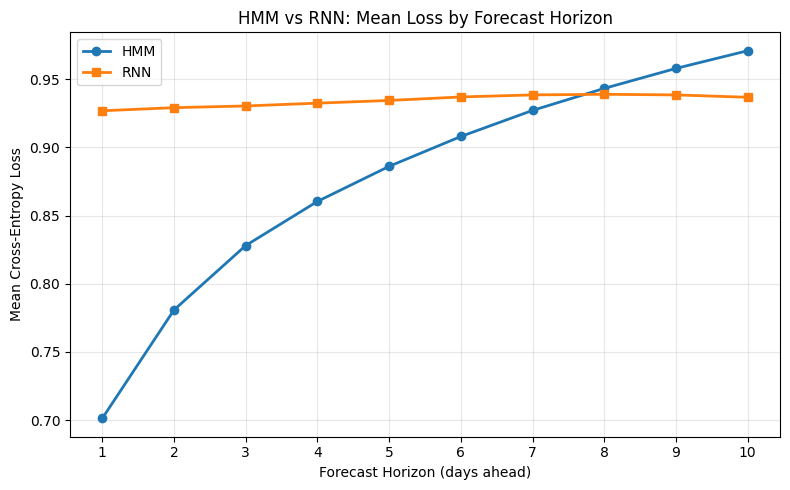

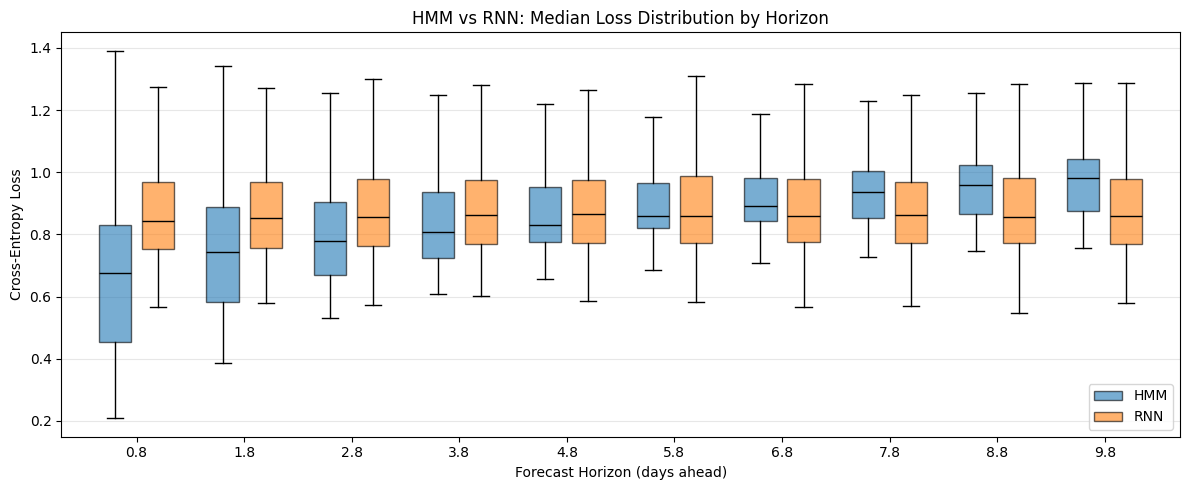

In [9]:
# --- Plot 1: Mean loss by forecast horizon ---
fig, ax = plt.subplots(figsize=(8, 5))
horizons = np.arange(1, forecast_horizon + 1)
ax.plot(horizons, hmm_loss_test.mean(axis=0), 'o-', label='HMM', linewidth=2)
ax.plot(horizons, rnn_loss_test.mean(axis=0), 's-', label='RNN', linewidth=2)
ax.set_xlabel('Forecast Horizon (days ahead)')
ax.set_ylabel('Mean Cross-Entropy Loss')
ax.set_title('HMM vs RNN: Mean Loss by Forecast Horizon')
ax.set_xticks(horizons)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: Loss distribution (boxplot side-by-side per horizon) ---
fig, ax = plt.subplots(figsize=(12, 5))
positions_hmm = horizons - 0.2
positions_rnn = horizons + 0.2

bp_hmm = ax.boxplot(hmm_loss_test, positions=positions_hmm, widths=0.3,
                     patch_artist=True, showfliers=False,
                     boxprops=dict(facecolor='#1f77b4', alpha=0.6),
                     medianprops=dict(color='black'), showmeans=False)
bp_rnn = ax.boxplot(rnn_loss_test, positions=positions_rnn, widths=0.3,
                     patch_artist=True, showfliers=False,
                     boxprops=dict(facecolor='#ff7f0e', alpha=0.6),
                     medianprops=dict(color='black'), showmeans=False)

ax.set_xlabel('Forecast Horizon (days ahead)')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('HMM vs RNN: Median Loss Distribution by Horizon')
ax.set_xticks(horizons)
ax.legend([bp_hmm['boxes'][0], bp_rnn['boxes'][0]], ['HMM', 'RNN'])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

/tmp/ipykernel_703135/4244222927.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


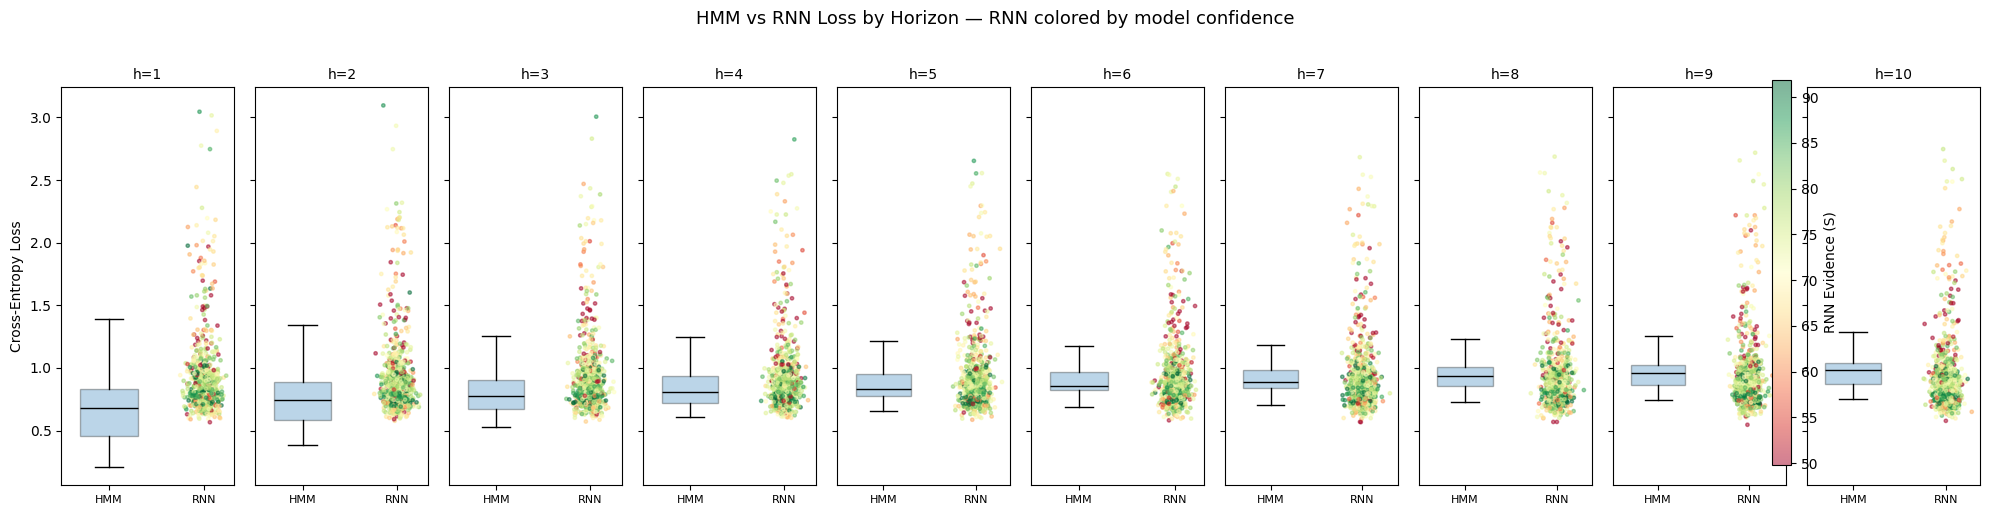

In [10]:
# Scatter: RNN loss colored by evidence, HMM boxplot as reference
fig, axes = plt.subplots(1, forecast_horizon, figsize=(20, 5), sharey=True)

for h in range(forecast_horizon):
    ax = axes[h]

    # HMM boxplot as background reference
    ax.boxplot(hmm_loss_test[:, h], positions=[0], widths=0.6,
               patch_artist=True, showfliers=False,
               boxprops=dict(facecolor='#1f77b4', alpha=0.3),
               medianprops=dict(color='black'))

    # RNN scatter colored by evidence S
    sc = ax.scatter(
        np.random.normal(1, 0.08, n_samples_test),  # jitter x position
        rnn_loss_test[:, h],
        c=rnn_s_test[:, h],
        cmap='RdYlGn',  # red=low evidence, green=high evidence
        s=6, alpha=0.5,
        vmin=np.percentile(rnn_s_test, 5),
        vmax=np.percentile(rnn_s_test, 95),
    )

    ax.set_title(f'h={h+1}', fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['HMM', 'RNN'], fontsize=8)
    if h == 0:
        ax.set_ylabel('Cross-Entropy Loss')

fig.colorbar(sc, ax=axes, orientation='vertical', fraction=0.015, pad=0.02, label='RNN Evidence (S)')
fig.suptitle('HMM vs RNN Loss by Horizon — RNN colored by model confidence', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

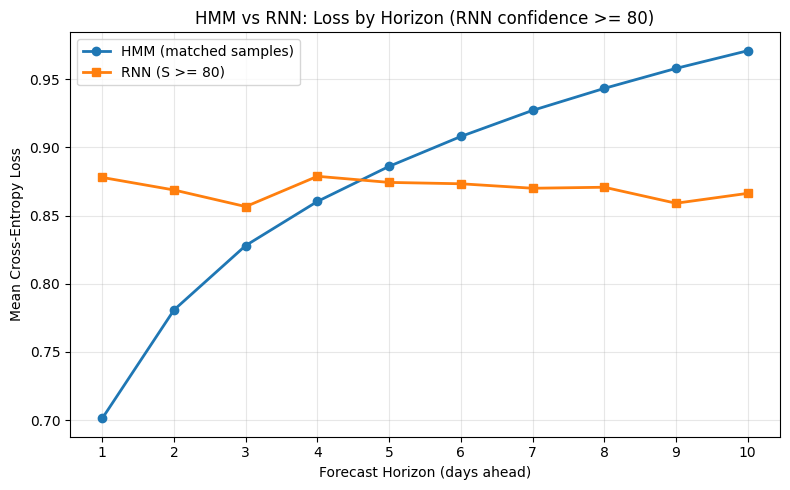

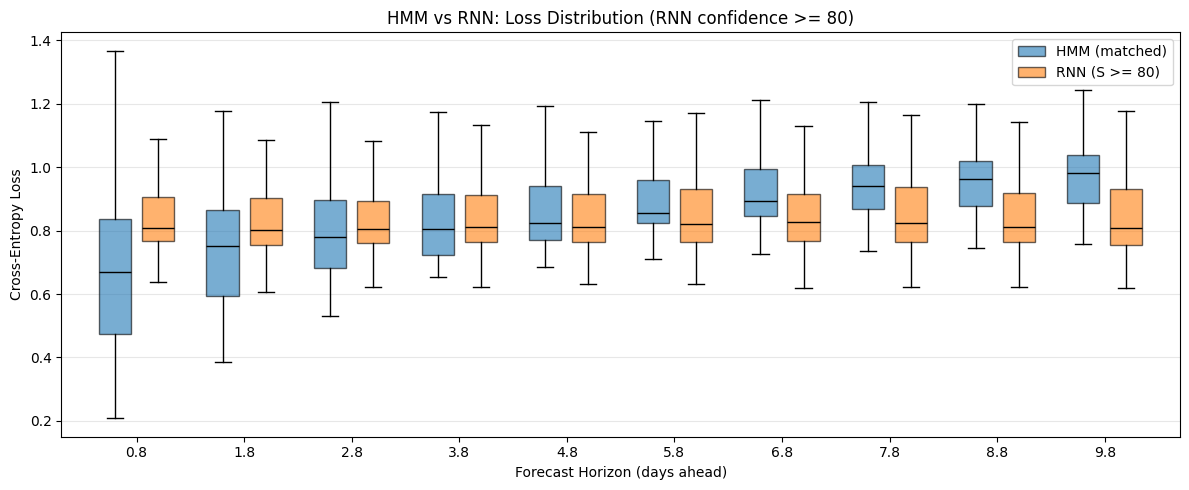

In [22]:
confidence_threshold = 80

# --- Plot 1: Mean loss by horizon (RNN filtered by S >= threshold) ---
fig, ax = plt.subplots(figsize=(8, 5))
horizons = np.arange(1, forecast_horizon + 1)

hmm_mean = np.zeros(forecast_horizon)
rnn_mean = np.zeros(forecast_horizon)
rnn_count = np.zeros(forecast_horizon)

mask_2d = np.zeros((n_samples_test, forecast_horizon), dtype=bool)
for h in range(forecast_horizon):
    mask = rnn_s_test[:, h] >= confidence_threshold
    mask = np.array(mask[:, 0])
    mask_2d[:, h] = mask
    hmm_mean[h] = hmm_loss_test[:, h].mean()
    rnn_mean[h] = rnn_loss_test[mask, h].mean()

ax.plot(horizons, hmm_mean, 'o-', label='HMM (matched samples)', linewidth=2)
ax.plot(horizons, rnn_mean, 's-', label=f'RNN (S >= {confidence_threshold})', linewidth=2)
ax.set_xlabel('Forecast Horizon (days ahead)')
ax.set_ylabel('Mean Cross-Entropy Loss')
ax.set_title(f'HMM vs RNN: Loss by Horizon (RNN confidence >= {confidence_threshold})')
ax.set_xticks(horizons)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: Boxplot side-by-side (filtered) ---
fig, ax = plt.subplots(figsize=(12, 5))
positions_hmm = horizons - 0.2
positions_rnn = horizons + 0.2

hmm_filtered = [hmm_loss_test[mask_2d[:, h], h] for h in range(forecast_horizon)]
rnn_filtered = [rnn_loss_test[mask_2d[:, h], h] for h in range(forecast_horizon)]

bp_hmm = ax.boxplot(hmm_filtered, positions=positions_hmm, widths=0.3,
                     patch_artist=True, showfliers=False,
                     boxprops=dict(facecolor='#1f77b4', alpha=0.6),
                     medianprops=dict(color='black'))
bp_rnn = ax.boxplot(rnn_filtered, positions=positions_rnn, widths=0.3,
                     patch_artist=True, showfliers=False,
                     boxprops=dict(facecolor='#ff7f0e', alpha=0.6),
                     medianprops=dict(color='black'))

ax.set_xlabel('Forecast Horizon (days ahead)')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title(f'HMM vs RNN: Loss Distribution (RNN confidence >= {confidence_threshold})')
ax.set_xticks(horizons)
ax.legend([bp_hmm['boxes'][0], bp_rnn['boxes'][0]], ['HMM (matched)', f'RNN (S >= {confidence_threshold})'])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Plot of rnn_loss - hmm_loss

In [34]:
rnn_s_test[:, 0]

array([[79.64295 ],
       [78.149506],
       [77.43636 ],
       [76.443085],
       [72.35876 ],
       [79.4534  ],
       [76.2394  ],
       [61.87525 ],
       [68.74719 ],
       [59.98137 ],
       [59.81139 ],
       [43.85811 ],
       [58.476395],
       [66.20551 ],
       [60.41719 ],
       [62.120056],
       [73.407394],
       [73.46324 ],
       [71.03613 ],
       [72.901115],
       [72.960075],
       [72.20099 ],
       [69.34224 ],
       [72.1012  ],
       [70.70562 ],
       [82.10062 ],
       [85.64383 ],
       [81.30783 ],
       [75.28457 ],
       [73.67688 ],
       [74.28718 ],
       [90.491135],
       [91.273964],
       [87.90789 ],
       [63.278847],
       [69.05189 ],
       [61.388565],
       [67.589455],
       [62.555107],
       [63.410583],
       [71.89397 ],
       [70.58091 ],
       [72.04504 ],
       [57.261566],
       [39.633522],
       [54.752525],
       [42.207527],
       [47.07545 ],
       [57.56832 ],
       [69.187126],


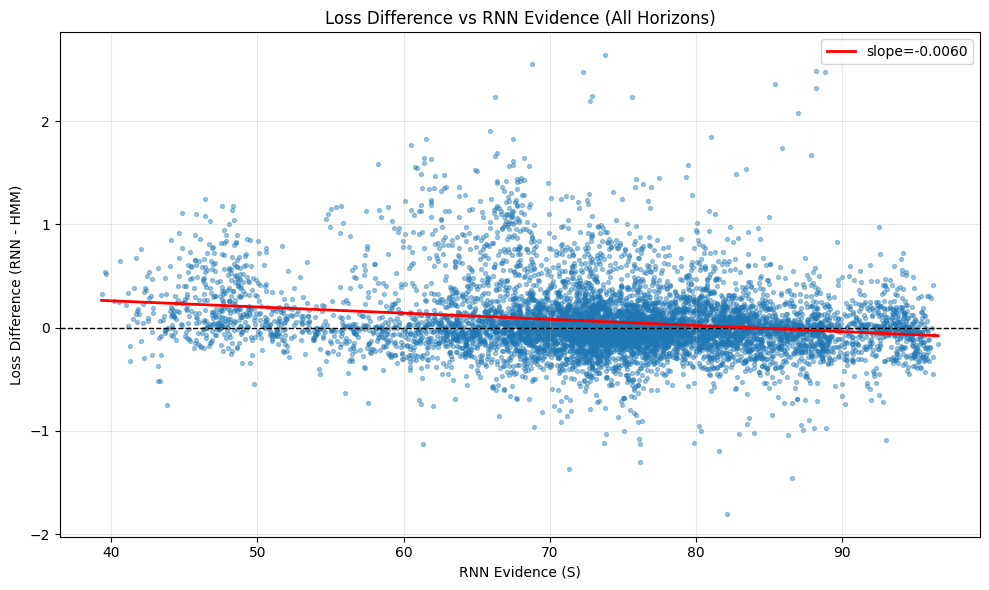

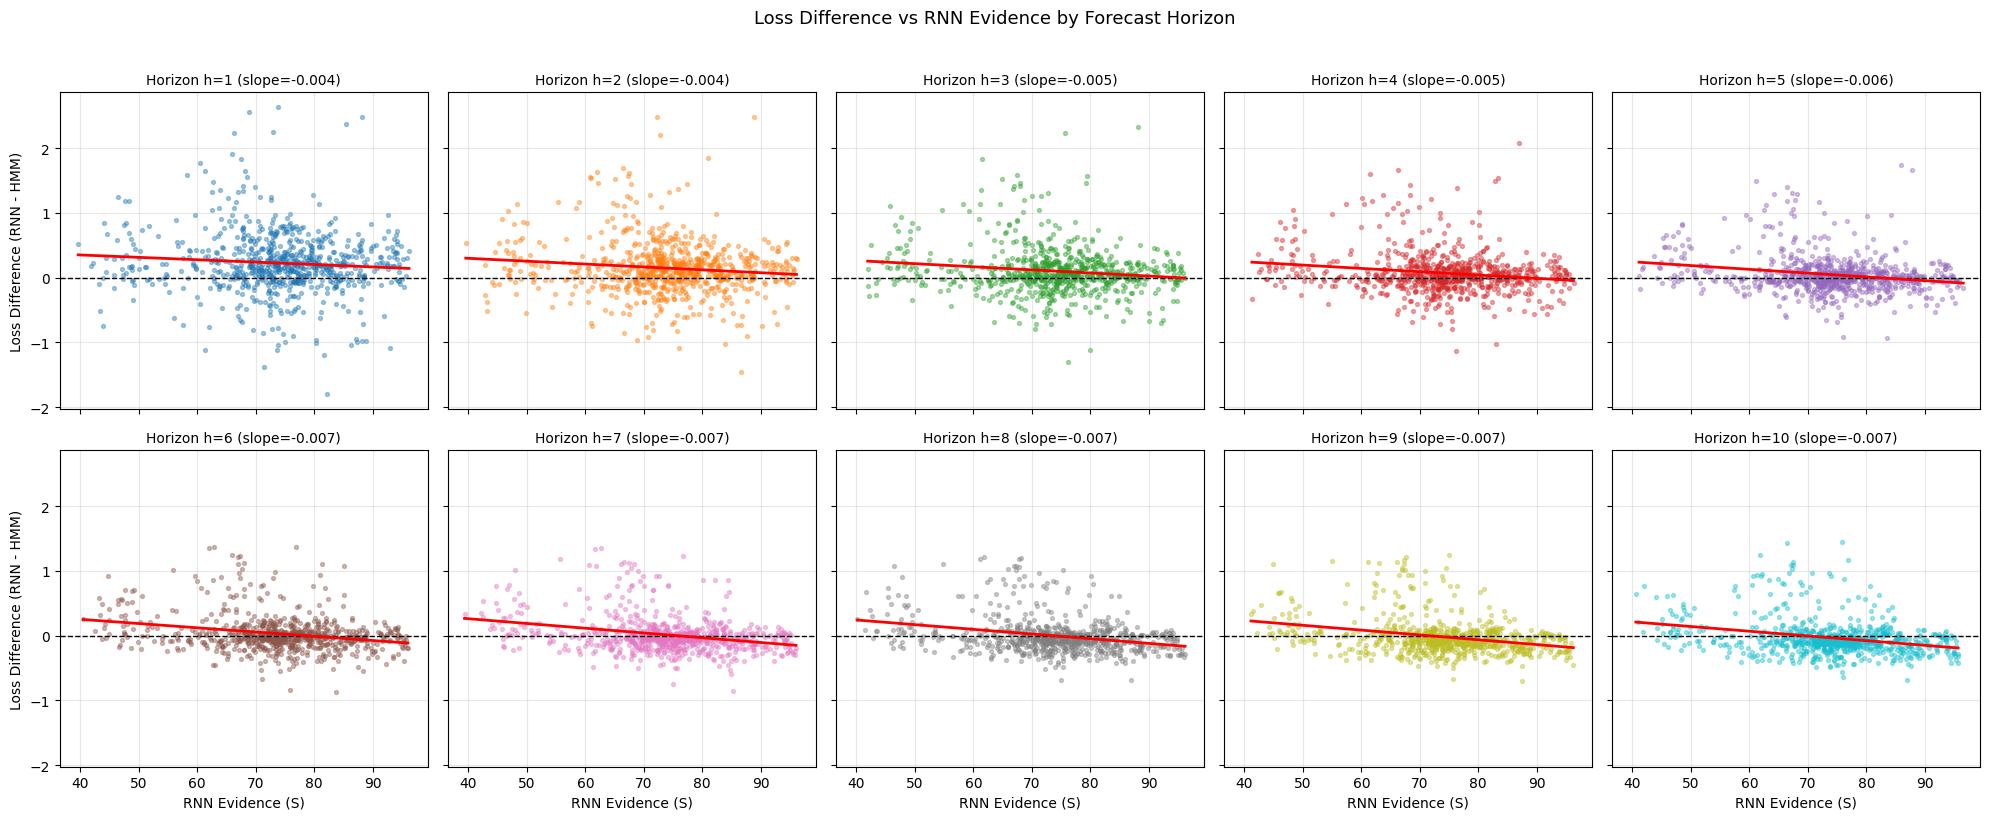

In [35]:
loss_diff_test = rnn_loss_test - hmm_loss_test

loss_diff_flat = loss_diff_test.flatten()
s_flat_diff = rnn_s_test.flatten()

# Overall scatter across all horizons
plt.figure(figsize=(10, 6))
plt.scatter(s_flat_diff, loss_diff_flat, alpha=0.4, s=8)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
# Linear trend line
z = np.polyfit(s_flat_diff, loss_diff_flat, 1)
x_line = np.linspace(s_flat_diff.min(), s_flat_diff.max(), 100)
plt.plot(x_line, np.polyval(z, x_line), color='red', linewidth=2, label=f'slope={z[0]:.4f}')
plt.legend()
plt.xlabel('RNN Evidence (S)')
plt.ylabel('Loss Difference (RNN - HMM)')
plt.title('Loss Difference vs RNN Evidence (All Horizons)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter by horizon
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()

for h in range(forecast_horizon):
    ax = axes[h]
    ax.scatter(rnn_s_test[:, h], loss_diff_test[:, h], alpha=0.4, s=8, c=f'C{h}')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    # Linear trend line per horizon
    z = np.polyfit(rnn_s_test[:, h].flatten(), loss_diff_test[:, h].flatten(), 1)
    x_line = np.linspace(rnn_s_test[:, h].min(), rnn_s_test[:, h].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), color='red', linewidth=2)
    ax.set_title(f'Horizon h={h+1} (slope={z[0]:.3f})', fontsize=10)
    ax.grid(True, alpha=0.3)
    if h % 5 == 0:
        ax.set_ylabel('Loss Difference (RNN - HMM)')
    if h >= 5:
        ax.set_xlabel('RNN Evidence (S)')

fig.suptitle('Loss Difference vs RNN Evidence by Forecast Horizon', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
rnn_probs_valid[50, :, :]

array([[0.03922063, 0.42699128, 0.5337881 ],
       [0.04596611, 0.43333873, 0.52069515],
       [0.09471299, 0.42668405, 0.47860298],
       [0.18269052, 0.4050976 , 0.41221187],
       [0.1181091 , 0.41183066, 0.47006026],
       [0.0889126 , 0.4140123 , 0.49707508],
       [0.0873785 , 0.4170285 , 0.49559304],
       [0.0900303 , 0.42094037, 0.48902935],
       [0.08783242, 0.42441222, 0.48775536],
       [0.05868497, 0.4230928 , 0.5182222 ]], dtype=float32)

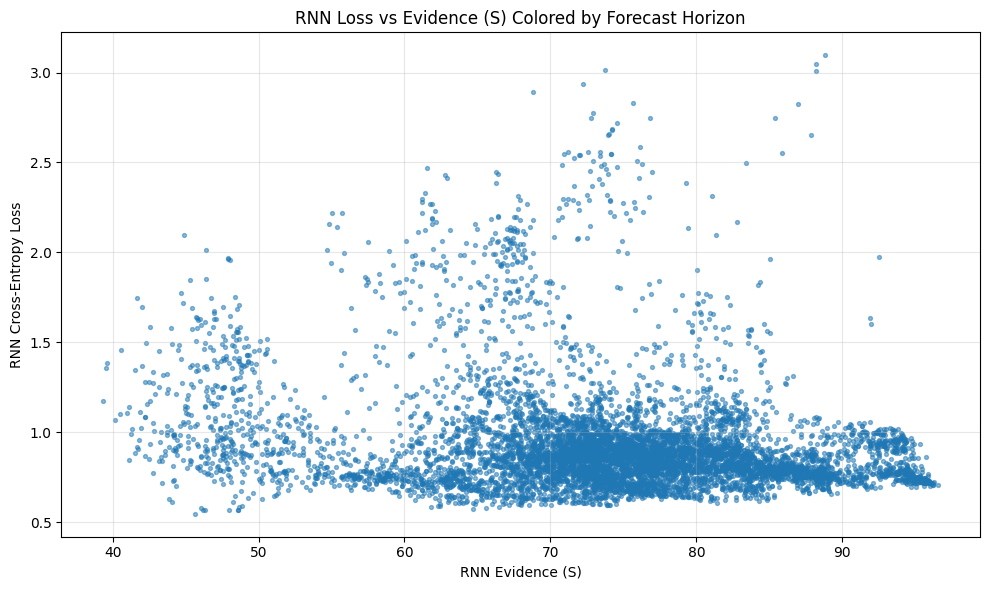

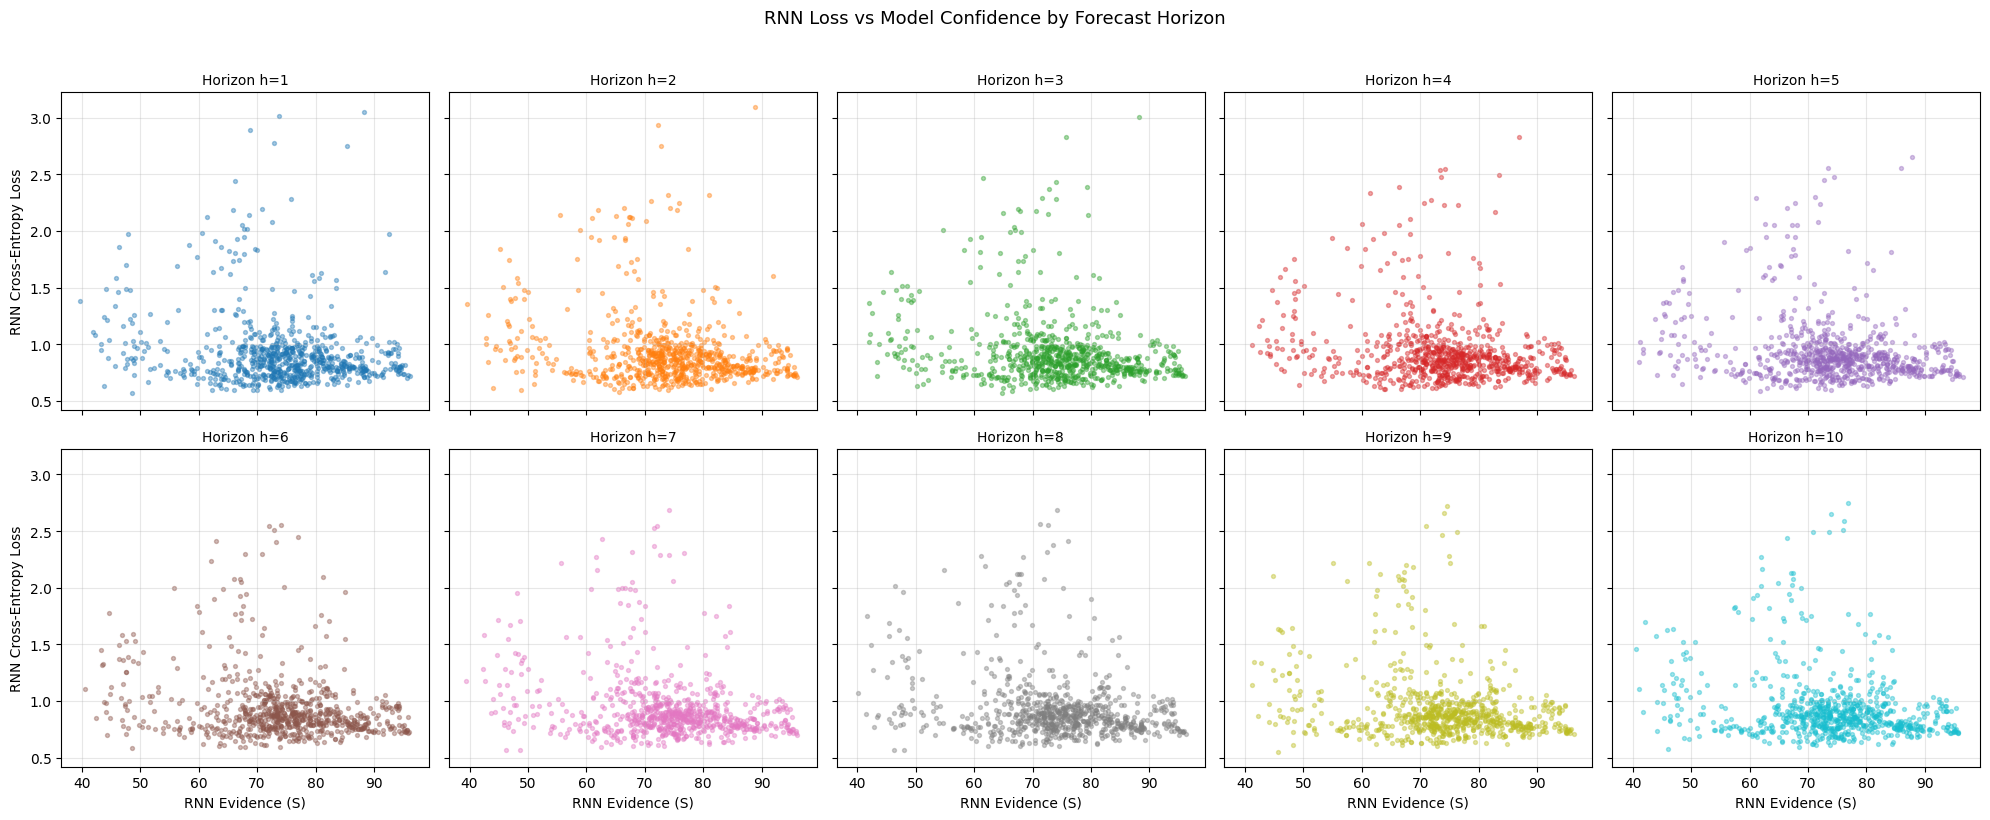

In [19]:
# Scatter plot of RNN loss vs RNN evidence (S), colored by forecast horizon
# Flatten s and loss across all horizons, with horizon label
s_flat = rnn_s_test[:, :, 0].flatten()
loss_flat = rnn_loss_test.flatten()
fig = plt.figure(figsize=(10, 6))
scatter = plt.scatter(s_flat, loss_flat, alpha=0.5, s=8)
plt.xlabel('RNN Evidence (S)')
plt.ylabel('RNN Cross-Entropy Loss')
plt.title('RNN Loss vs Evidence (S) Colored by Forecast Horizon')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True, sharex=True)
axes = axes.flatten()

for h in range(forecast_horizon):
    ax = axes[h]
    s_h = rnn_s_test[:, h, 0]
    loss_h = rnn_loss_test[:, h]

    sc = ax.scatter(s_h, loss_h, alpha=0.4, s=8, c=f'C{h}')
    ax.set_title(f'Horizon h={h+1}', fontsize=10)
    ax.grid(True, alpha=0.3)
    if h % 5 == 0:
        ax.set_ylabel('RNN Cross-Entropy Loss')
    if h >= 5:
        ax.set_xlabel('RNN Evidence (S)')

fig.suptitle('RNN Loss vs Model Confidence by Forecast Horizon', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
